In [ ]:
# demo of cvtransformer on simple oscillator data set

# identical to v1 demo but uses the v2 model which has:
# 1) more efficient forward pass
# 2) potential for extra numeric head blocks to allow for increased numeric expressiveness

# the extra expressiveness does not provide benefit in this small case where vocab is so small

In [5]:
import torch   
import yaml
import numpy as np
import matplotlib.pyplot as plt
import time
import dataclasses

from multivariategpt import GPTV2, GPTConfigV2


In [6]:
# initialize model from config. 
# V2 with n_head_blocks==0 is identical in parameter count with v1

config_path = "./cv_demo.yaml"  # replace with actual path
with open(config_path, "r") as f:
    config_yaml = yaml.safe_load(f)
config = config_yaml['model']
# config['n]

model = GPTV2(GPTConfigV2(**config))
n_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {n_params}")

Number of parameters: 15552


In [7]:
# will re-initialize with 1 block just to show the difference
config_path = "./cv_demo.yaml"  # replace with actual path
with open(config_path, "r") as f:
    config_yaml = yaml.safe_load(f)
config = config_yaml['model']
config['n_head_blocks']=1

model = GPTV2(GPTConfigV2(**config))
n_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {n_params}")

Number of parameters: 22608


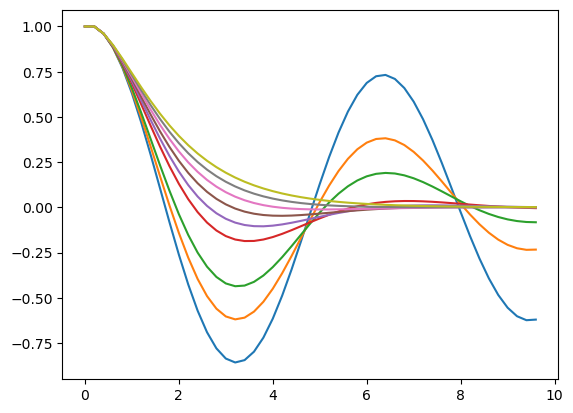

In [8]:
# now we will train this model on the oscillator task from multivariate gpt
# the model is trained on trajectories of simple harmonic oscillators.
#  - each trajectory has [coefficient, position1, position2,...]
#  - the model is trained on 9 different coefficients and tested on 2 held out coefficients


data = torch.load('./multi_oscillator_full_data.pt',weights_only=False)
c_full, v_full, c_t_full, v_t_full, t = data

# remove the held out trajectories
c     = np.delete(c_full, 0, axis=0)
v     = np.delete(v_full, 0, axis=0)
c_t   = np.delete(c_t_full, 0, axis=0)
v_t   = np.delete(v_t_full, 0, axis=0)

c     = np.delete(c, 3, axis=0)
v     = np.delete(v, 3, axis=0)
c_t   = np.delete(c_t, 3, axis=0)
v_t   = np.delete(v_t, 3, axis=0)

# plot the training trajectories
for i in range(9):
    plt.plot(t[:-1],v[i][1:].detach().numpy())

In [9]:
# fit the model with a simple training loop

# you will see the loss go negative:
#  - cross entropy loss is on a discrete distribution which is a probability mass function. the negative log likelihood is lower bounded by 0
#  - the value loss is from gaussian which is a probablity density function. the negative log likelihood is unbounded below and can go negative

# for this simple example we keep variance fixed for the first 2000 iterations so the model learns to shift the mean correctly first
# in larger more diverse data sets this is not necessary

# it is critcal, however, to center and scale numeric values because on intit, the model estimate mean 0 and variance 1 for all outputs
# any far-away targets can lead to the model just learning to increase variance to reduce loss rather than learning to predict the mean correctly

optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'],weight_decay=config['weight_decay'])
max_iters = config['max_iters']
iter = 0


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=max_iters, eta_min=1e-6
)

t0 = time.time()
t0_global = t0
B, T = c.shape

while iter < max_iters:
    x_c, x_v_l, x_v_s, c_loss, v_loss, loss = model(c, v, c_t, v_t)

    # start learning variance after iteration 2000
    if iter > 2000 and model.fit_scale is False:
        model.fit_scale = True

    t1 = time.time()
    dt = t1 - t0
    t0 = t1
    if iter % 100 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(f"iter (global) {iter}: | train loss {loss:.4f} | val loss {'na'} | "
              f"dt {dt*1000:.2f}ms | tok/sec {B*T/dt:.2f} | lr {current_lr:.2e}")

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    scheduler.step()  # update learning rate
    iter += 1

print(f"Total training time: {time.time() - t0_global:.1f}s")


iter (global) 0: | train loss 2.3604 | val loss na | dt 3.00ms | tok/sec 150142.14 | lr 1.00e-04
iter (global) 100: | train loss 1.9620 | val loss na | dt 6.18ms | tok/sec 72789.70 | lr 1.00e-04
iter (global) 200: | train loss 1.8559 | val loss na | dt 6.10ms | tok/sec 73782.76 | lr 1.00e-04
iter (global) 300: | train loss 1.7768 | val loss na | dt 6.41ms | tok/sec 70214.53 | lr 9.99e-05
iter (global) 400: | train loss 1.7290 | val loss na | dt 6.50ms | tok/sec 69179.96 | lr 9.99e-05
iter (global) 500: | train loss 1.6993 | val loss na | dt 6.67ms | tok/sec 67427.72 | lr 9.98e-05
iter (global) 600: | train loss 1.6791 | val loss na | dt 6.61ms | tok/sec 68069.71 | lr 9.98e-05
iter (global) 700: | train loss 1.6650 | val loss na | dt 6.21ms | tok/sec 72498.92 | lr 9.97e-05
iter (global) 800: | train loss 1.6547 | val loss na | dt 6.27ms | tok/sec 71765.66 | lr 9.96e-05
iter (global) 900: | train loss 1.6470 | val loss na | dt 6.81ms | tok/sec 66040.48 | lr 9.95e-05
iter (global) 1000: |

In [9]:
# seed the model with just the viscous coefficients and look at ability to reproduce full trajectories
c_seed = c_full[:,:1]
v_seed = v_full[:,:1]
c_gen,v_gen = model.generate(c_seed,v_seed,max_new_tokens=40)

(array([-1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,  2. ]),
 [Text(0, -1.5, '−1.5'),
  Text(0, -1.0, '−1.0'),
  Text(0, -0.5, '−0.5'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.5, '0.5'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.5, '1.5'),
  Text(0, 2.0, '2.0')])

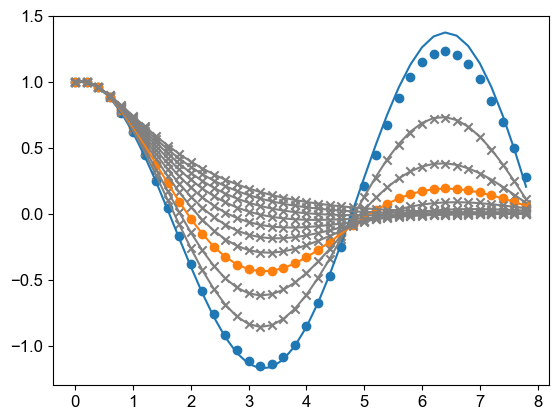

In [10]:
# show the results. the MV model learns to generalize
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'Arial'

for i in range(11):
    if i==3 or i == 0:
        plt.plot(t[:40], v_full[i].detach().numpy().squeeze()[1:41])
        plt.scatter(t[:40], v_gen[i].detach().numpy().squeeze()[1:], marker='o')
    else:
        plt.plot(t[:40], v_full[i].detach().numpy().squeeze()[1:41],color='gray')
        plt.scatter(t[:40], v_gen[i].detach().numpy().squeeze()[1:], marker='x',color='gray')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)